## Dataset Variables
H2H2 collisions dataset by Benjamin contains the following columns: b,Etr,Er1,Er2,Etrp,Er1p,Er2p.

# Mixeture Density Networks (MDN)

A Mixture Density Network (MDN) predicts means, variances, and mixture coefficients for a mixture of Gaussian distributions, allowing it to model complex output distributions conditioned on input features. This is particularly useful for modeling the scattering kernel in our oxygen dataset, where the output velocity distributions depend on the input velocities.

The MDN creates a model that predicts conditional probabilities using
$$ 
p(y|x) = \sum_{i=1}^{K} \pi_i(x) \mathcal{N}(y|\mu_i(x), \sigma_i(x)) 
$$
where $K$ is the number of mixture components, $\pi_i(x)$ are the mixture coefficients, and $\mathcal{N}(y|\mu_i(x), \sigma_i(x))$ are Gaussian distributions with means $\mu_i(x)$ and standard deviations $\sigma_i(x)$.

The dimensions of each variable is:
$\pi$: K
$\mu$: K x D
$\sigma$: K x D
where D is the output dimension.

#### Dataset Preparation

Input mean: [6049.673828125, 0.4815983474254608, 0.5023599863052368]
Input std : [2097.983154296875, 0.1984938532114029, 0.23896823823451996]
Output mean: [0.48537585139274597, 0.5032348036766052]
Output std : [0.21043580770492554, 0.25154367089271545]
Epoch 1, Training Loss: 2.8862
Epoch 1, Validation Loss: 2.6847
Epoch 2, Training Loss: 2.5150
Epoch 2, Validation Loss: 2.3661
Epoch 3, Training Loss: 2.1893
Epoch 3, Validation Loss: 2.0088
Epoch 4, Training Loss: 1.8127
Epoch 4, Validation Loss: 1.6254
Epoch 5, Training Loss: 1.5009
Epoch 5, Validation Loss: 1.3430
Epoch 6, Training Loss: 1.2697
Epoch 6, Validation Loss: 1.1114
Epoch 7, Training Loss: 1.0803
Epoch 7, Validation Loss: 0.9588
Epoch 8, Training Loss: 0.9648
Epoch 8, Validation Loss: 0.8819
Epoch 9, Training Loss: 0.9226
Epoch 9, Validation Loss: 0.8291
Epoch 10, Training Loss: 0.8743
Epoch 10, Validation Loss: 0.7707
Epoch 11, Training Loss: 0.8337
Epoch 11, Validation Loss: 0.7509
Epoch 12, Training Loss: 0.8184
Epoch 1

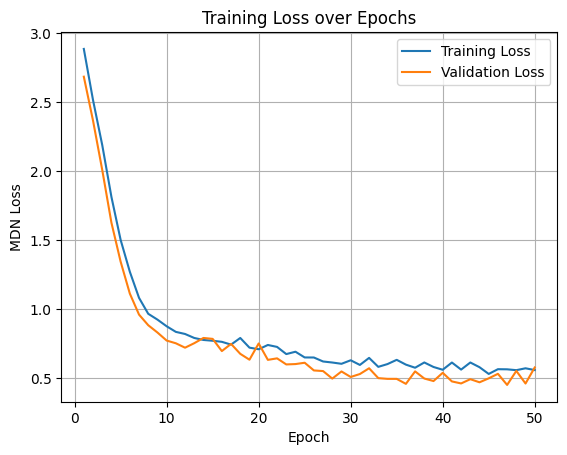

In [34]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset, Subset
import torch.nn as nn
import torch.nn.functional as F

# import data
DATA = "datasets/H2H2_collisions_benjamin.csv"
rawdata = np.loadtxt(DATA, delimiter=',', skiprows=1)

# Convert to the variable set (Ec, \eta_trans, \eta_rot_A)
inputdata = np.zeros((rawdata.shape[0], 3))
inputdata[:,0] = np.sum(rawdata[:,1:4], axis=1)
inputdata[:,1] = rawdata[:,1]/inputdata[:,0] 
inputdata[:,2] = rawdata[:,2] / np.sum(rawdata[:,2:4], axis=1)

outputdata = np.zeros((rawdata.shape[0], 2))
# outputdata[:,0] = np.sum(rawdata[:,4:7], axis=1)
outputdata[:,0] = rawdata[:,4]/np.sum(rawdata[:,4:7], axis=1)
outputdata[:,1] = rawdata[:,5]/ np.sum(rawdata[:,5:7], axis=1)

# Create Dataloaders for training and validation (with normalization)
inputs = torch.tensor(inputdata, dtype=torch.float32)
outputs = torch.tensor(outputdata, dtype=torch.float32)

dataset = TensorDataset(inputs, outputs)

# Set machine learning parameters
train_size = int(0.7 * len(dataset))
val_size = len(dataset) - train_size
batch_size = 128

# Create train/validation split 
generator = torch.Generator().manual_seed(0)
train_subset, val_subset = torch.utils.data.random_split(dataset, [train_size, val_size], generator=generator)

train_idx = torch.tensor(train_subset.indices, dtype=torch.long)
val_idx = torch.tensor(val_subset.indices, dtype=torch.long)

# Compute normalization statistics on training data only
eps = 1e-8
in_mean = inputs[train_idx].mean(dim=0, keepdim=True)
in_std = inputs[train_idx].std(dim=0, unbiased=False, keepdim=True).clamp_min(eps)
out_mean = outputs[train_idx].mean(dim=0, keepdim=True)
out_std = outputs[train_idx].std(dim=0, unbiased=False, keepdim=True).clamp_min(eps)

# Normalize tensors, then re-wrap
inputs_norm = (inputs - in_mean) / in_std
outputs_norm = (outputs - out_mean) / out_std
dataset_norm = TensorDataset(inputs_norm, outputs_norm)

train_dataset = Subset(dataset_norm, train_idx.tolist())
val_dataset = Subset(dataset_norm, val_idx.tolist())

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

print("Input mean:", in_mean.flatten().tolist())
print("Input std :", in_std.flatten().tolist())
print("Output mean:", out_mean.flatten().tolist())
print("Output std :", out_std.flatten().tolist())

# Model Definition
class MixtureDensityNetwork(nn.Module):
    def __init__(self, input_dim, output_dim, num_mixtures, hidden_dim=128):
        super().__init__()
        self.K = num_mixtures
        self.D = output_dim

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        self.pi_layer = nn.Linear(hidden_dim, self.K)
        self.mu_layer = nn.Linear(hidden_dim, self.K * self.D)
        self.sigma_layer = nn.Linear(hidden_dim, self.K * self.D)

    def forward(self, x):
        h = self.net(x)

        # Mixture weights
        pi = F.softmax(self.pi_layer(h), dim=-1)

        # Means
        mu = self.mu_layer(h)
        mu = mu.view(-1, self.K, self.D)

        # Standard deviations
        sigma = self.sigma_layer(h)
        sigma = F.softplus(sigma) + 1e-6  # Ensure positivity
        # sigma = torch.exp(sigma)
        sigma = sigma.view(-1, self.K, self.D)

        return pi, mu, sigma

# Define loss function
def mdn_loss(pi, mu, sigma, y):
    """
    Computes the negative log-likelihood loss for a Mixture Density Network.
    Args:
        pi: Mixture weights, shape (batch_size, K)
        mu: Means of the mixtures, shape (batch_size, K, D)
        sigma: Standard deviations of the mixtures, shape (batch_size, K, D)
        y: Target values, shape (batch_size, D)
    """
    y = y.unsqueeze(1)  # Shape (batch_size, 1, D)

    # Gaussian probability density function
    log_prob = -0.5 * (
        torch.sum(((y - mu) / sigma) ** 2, dim=2)
        + torch.sum(torch.log(sigma ** 2), dim=2)
        + mu.size(2) * torch.log(torch.tensor(2 * torch.pi))
    )  # Shape (batch_size, K)

    # Weighted log probabilities
    weighted_log_prob = log_prob + torch.log(pi + 1e-8)
    log_sum_exp = torch.logsumexp(weighted_log_prob, dim=1) 

    return -torch.mean(log_sum_exp)

# Training the model
K = 5
output_dim = 2

model = MixtureDensityNetwork(
    input_dim=3,
    output_dim=output_dim,
    num_mixtures=K
)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
num_epochs = 50
train_loss_hist = np.zeros(num_epochs)
val_loss_hist = np.zeros(num_epochs)

for epoch in range(num_epochs):
    # Training loop
    model.train()
    train_loss = 0.0
    for inputs, outputs in train_loader:
        optimizer.zero_grad()
        pi, mu, sigma = model(inputs)
        loss = mdn_loss(pi, mu, sigma, outputs)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
    train_loss /= len(train_loader)
    train_loss_hist[epoch] = train_loss
    print(f"Epoch {epoch+1}, Training Loss: {train_loss:.4f}")

    # Validation loop
    model.eval()
    with torch.no_grad():
        val_loss = 0.0
        for inputs, outputs in val_loader:
            pi, mu, sigma = model(inputs)
            loss = mdn_loss(pi, mu, sigma, outputs)
            val_loss += loss.item()

        val_loss /= len(val_loader)
        val_loss_hist[epoch] = val_loss
    print(f"Epoch {epoch+1}, Validation Loss: {val_loss_hist[epoch]:.4f}")

# save model
torch.save(model.state_dict(), "mdn_h2h2_collision_model.pth")


# Plot loss
import matplotlib.pyplot as plt

plt.plot(range(1, num_epochs + 1), train_loss_hist, label='Training Loss')
plt.plot(range(1, num_epochs + 1), val_loss_hist, label='Validation Loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('MDN Loss')
plt.title('Training Loss over Epochs')
plt.grid()
plt.show()

In [35]:
# Sample from the trained MDN
def sample_mdn(model, inputdata):
    model.eval()
    with torch.no_grad():
        pi, mu, sigma = model(inputdata)

        # N is number of data points, K is number of mixtures, D is output dimension
        N, K, D = mu.shape
        samples = np.zeros((N, D))

        # Reconstruct distribution per data point
        for i in range(N):
            # Sample a mixture component based on pi
            component = np.random.choice(K, p=pi[i].numpy())

            # Sample from the selected Gaussian
            sampled_point = np.random.normal(
                loc=mu[i, component].numpy(),
                scale=sigma[i, component].numpy()
            )
            samples[i] = sampled_point


    return samples

In [39]:
from mdn_utils import plot_scattering_comparison
mdn_model = MixtureDensityNetwork(
    input_dim=3,
    output_dim=2,
    num_mixtures=5
)
mdn_model.load_state_dict(
    torch.load("mdn_h2h2_collision_model.pth")
)


# plot comparison
plot_scattering_comparison(np.column_stack((inputdata, outputdata)),mdn_model)

TypeError: linear(): argument 'input' (position 1) must be Tensor, not numpy.ndarray